# Проклятие размерности и распознавание изображений методом kNN

Решения задач о равномерном распределении в единичном гиперкубе $[0,1]^m \subset \mathbb{R}^m$ (выборка из $N$ элементов) и задача распознавания изображений.

**Содержание**

1. **(а)** почти все точки выборки лежат около границы $m$-мерного гиперкуба (подход, применённый при рассмотрении $m$-мерной сферы);
2. **(б)** длина ребра $l_m(p)$ гиперкуба, содержащего долю $p$ точек; оценки $l_5(0.01)$, $l_5(0.1)$, $l_{20}(0.01)$, $l_{20}(0.1)$;
3. **(в)** евклидовы расстояния между точками выборки: достаточно большие и примерно одинаковые; окрестности, содержащие даже немного точек, должны иметь большой радиус;
4. **(г)** расстояния Чебышёва между почти всеми точками выборки достаточно велики;
5. **Задача 4** — распознавание растровых изображений методом ближайшего соседа: равномерное и неравномерное зашумление, сравнение мер близости ($L_1$, $L_2$, $L_\infty$, косинусная) для бинарных изображений и изображений в градациях серого при различных $k$.

*Зависимости:* `numpy`, `matplotlib`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 100


: 

## Задача (а). Почти все точки — около границы гиперкуба

**Подход, применённый при рассмотрении $m$-мерной сферы.** Для сферы радиуса $R$ доля объёма, лежащая во внешнем слое толщины $\varepsilon$ ($0<\varepsilon<R$), равна
$$1-\Bigl(1-\frac{\varepsilon}{R}\Bigr)^{m}\;\xrightarrow[m\to\infty]{}\;1,$$
то есть почти весь объём $m$-мерной сферы сосредоточен в тонком слое около её границы.

**Гиперкуб.** Для равномерного распределения в $[0,1]^m$ роль «внутренней сферы» играет внутренний куб $[\delta,\,1-\delta]^m$. Точка $x=(x_1,\dots,x_m)$ лежит вне внутреннего куба тогда и только тогда, когда её расстояние до границы гиперкуба меньше $\delta$, поскольку расстояние от $x$ до границы есть расстояние до ближайшей грани:
$$d\bigl(x,\,\partial[0,1]^m\bigr)=\min_i \min\bigl(x_i,\;1-x_i\bigr).$$
Вероятность попасть во внутренний куб равна отношению объёмов:
$$P\bigl(d(x,\partial[0,1]^m)\ge\delta\bigr)=(1-2\delta)^m\;\xrightarrow[m\to\infty]{}\;0$$
при любом фиксированном $\delta>0$. Следовательно,
$$P\bigl(d(x,\partial[0,1]^m)<\delta\bigr)=1-(1-2\delta)^m\;\xrightarrow[m\to\infty]{}\;1,$$

то есть **почти все точки выборки находятся около границы $m$-мерного гиперкуба**: уже при $m=100$ более $98\%$ точек лежат в слое толщины всего $\delta=0.05$.


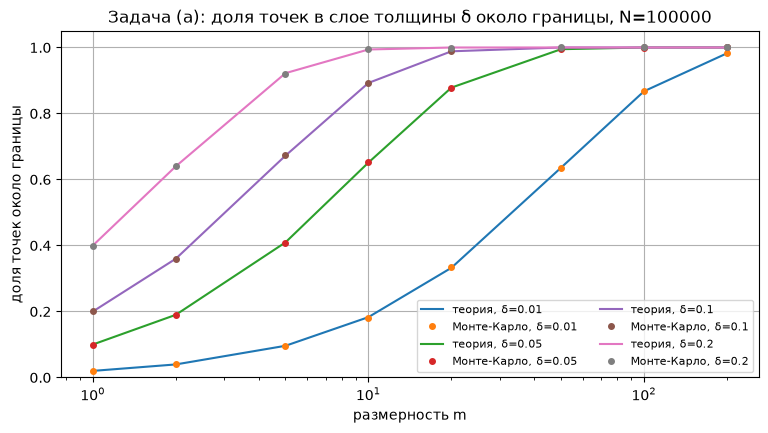

    m | δ=0.01    | δ=0.05    | δ=0.1     | δ=0.2    
-----------------------------------------------------
    1 | 0.0206   | 0.0995   | 0.2020   | 0.3975  
    2 | 0.0396   | 0.1893   | 0.3600   | 0.6406  
    5 | 0.0959   | 0.4076   | 0.6744   | 0.9210  
   10 | 0.1816   | 0.6527   | 0.8929   | 0.9942  
   20 | 0.3346   | 0.8787   | 0.9884   | 1.0000  
   50 | 0.6358   | 0.9947   | 1.0000   | 1.0000  
  100 | 0.8680   | 1.0000   | 1.0000   | 1.0000  
  200 | 0.9826   | 1.0000   | 1.0000   | 1.0000  


In [2]:
N = 100_000
ms = [1, 2, 5, 10, 20, 50, 100, 200]
deltas = [0.01, 0.05, 0.1, 0.2]

def frac_near_boundary(X, delta):
    d_min = np.minimum(X.min(axis=1), 1 - X.max(axis=1))
    return float(np.mean(d_min < delta))

emp = {d: [frac_near_boundary(rng.random((N, m)), d) for m in ms] for d in deltas}
theory = {d: 1 - (1 - 2 * d) ** np.asarray(ms, dtype=float) for d in deltas}

fig, ax = plt.subplots(figsize=(9, 4.5))
for d in deltas:
    ax.plot(ms, theory[d], "-", label=f"теория, δ={d}")
    ax.plot(ms, emp[d], "o", ms=4, label=f"Монте-Карло, δ={d}")
ax.set_xscale("log")
ax.set_xlabel("размерность m")
ax.set_ylabel("доля точек около границы")
ax.set_title(f"Задача (а): доля точек в слое толщины δ около границы, N={N}")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncol=2)
plt.show()

header = f"{'m':>5} | " + " | ".join(f"δ={d:<7}" for d in deltas)
print(header)
print("-" * len(header))
for i, m in enumerate(ms):
    print(f"{m:>5} | " + " | ".join(f"{emp[d][i]:<8.4f}" for d in deltas))


## Задача (б). Длина ребра $l_m(p)$

Для равномерного распределения в единичном гиперкубе $[0,1]^m$ доля точек внутри осевого подгиперкуба с ребром $l$ (целиком лежащего внутри куба) равна отношению объёмов $l^m/1=l^m$. Чтобы такой подгиперкуб содержал долю $p$ точек выборки, нужно $l^m=p$, откуда

$$\boxed{\,l_m(p)=p^{1/m}\,}$$

При $m\to\infty$ для любого фиксированного $p>0$ имеем $l_m(p)\to 1$: чтобы «накрыть» даже небольшую долю точек, гиперкуб должен занимать почти весь единичный куб — ещё одно проявление проклятия размерности.

**Требуемые оценки:**

| $p$ | $l_5(p)=p^{1/5}$ | $l_{20}(p)=p^{1/20}$ |
|---|---|---|
| $0.01$ | $0.01^{0.2}\approx 0.398$ | $0.01^{0.05}\approx 0.794$ |
| $0.1$ | $0.1^{0.2}\approx 0.631$ | $0.1^{0.05}\approx 0.891$ |

Например, в 20-мерном кубе подгиперкуб с ребром $0.89$ — почти совпадающий с исходным кубом — содержит лишь $10\%$ точек: остальные $90\%$ сосредоточены в оставшихся $10\%$ объёма, у границы.


Оценки l_m(p):
  l_5(0.01) = 0.3981
  l_5(0.1) = 0.6310
  l_20(0.01) = 0.7943
  l_20(0.1) = 0.8913

Проверка методом Монте-Карло (доля точек внутри [0, l]^m):
  m= 5, p=0.01 : теория 0.0100, эксперимент 0.0104
  m= 5, p=0.1  : теория 0.1000, эксперимент 0.0990
  m=20, p=0.01 : теория 0.0100, эксперимент 0.0099
  m=20, p=0.1  : теория 0.1000, эксперимент 0.1008


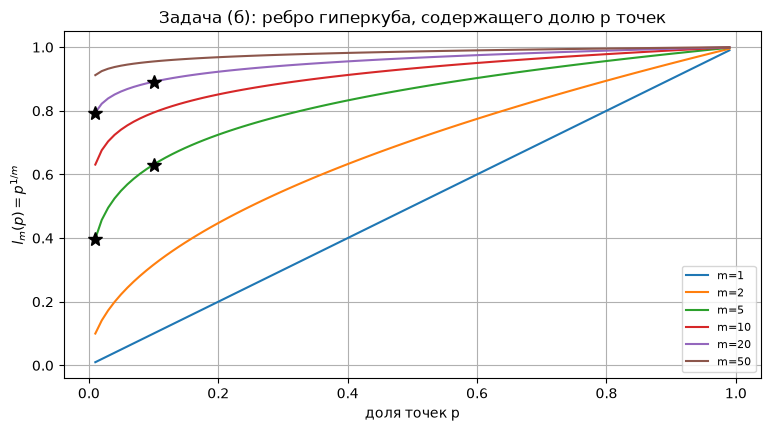

In [3]:
def l_m(p, m):
    return p ** (1.0 / m)

print("Оценки l_m(p):")
for p, m in [(0.01, 5), (0.1, 5), (0.01, 20), (0.1, 20)]:
    print(f"  l_{m}({p}) = {l_m(p, m):.4f}")

N = 200_000
print("\nПроверка методом Монте-Карло (доля точек внутри [0, l]^m):")
for p, m in [(0.01, 5), (0.1, 5), (0.01, 20), (0.1, 20)]:
    X = rng.random((N, m))
    frac = float(np.mean((X <= l_m(p, m)).all(axis=1)))
    print(f"  m={m:>2}, p={p:<5}: теория {p:.4f}, эксперимент {frac:.4f}")

ps = np.linspace(0.01, 0.99, 100)
fig, ax = plt.subplots(figsize=(9, 4.5))
for m in [1, 2, 5, 10, 20, 50]:
    ax.plot(ps, l_m(ps, m), label=f"m={m}")
for p, m in [(0.01, 5), (0.1, 5), (0.01, 20), (0.1, 20)]:
    ax.plot(p, l_m(p, m), "k*", ms=10)
ax.set_xlabel("доля точек p")
ax.set_ylabel(r"$l_m(p)=p^{1/m}$")
ax.set_title("Задача (б): ребро гиперкуба, содержащего долю p точек")
ax.legend(fontsize=8)
plt.show()


## Задача (в). Концентрация евклидовых расстояний

Пусть $X,Y$ — независимые случайные точки, равномерно распределённые в $[0,1]^m$. Тогда
$$\|X-Y\|^2=\sum_{i=1}^m (X_i-Y_i)^2,\qquad \mathbb{E}(X_i-Y_i)^2=\frac16,\qquad \mathbb{E}(X_i-Y_i)^4=\frac1{15},$$
откуда
$$\mathbb{E}\|X-Y\|^2=\frac{m}{6},\qquad \operatorname{Var}\|X-Y\|^2=m\Bigl(\frac1{15}-\frac1{36}\Bigr)=\frac{7m}{180}.$$
Относительное среднеквадратичное отклонение расстояния:
$$\frac{\sqrt{\operatorname{Var}\|X-Y\|^2}}{\mathbb{E}\|X-Y\|^2}=\sqrt{\frac{7}{5m}}\;\xrightarrow[m\to\infty]{}\;0.$$

**Вывод 1 (расстояния).** Типичное евклидово расстояние $\approx\sqrt{m/6}$ растёт как $\sqrt m$ (при $m=100$ это $\approx 4.1$ при длине диагонали куба $\sqrt{100}=10$), а его относительный разброс убывает как $1/\sqrt m$: **почти все евклидовы расстояния между точками выборки достаточно велики и примерно одинаковы** — расстояние до «ближайшего» соседа лишь немногим меньше расстояния до самых дальних точек.

**Вывод 2 (окрестности).** Даже максимальный шар, вписанный в единичный куб ($r=1/2$), содержит долю объёма
$$V_m\Bigl(\frac12\Bigr)=\frac{\pi^{m/2}}{2^m\,\Gamma\bigl(\frac m2+1\bigr)}\;\xrightarrow[m\to\infty]{}\;0$$
сверхэкспоненциально быстро, значит, почти все точки выборки лежат вне любого такого шара. Чтобы окрестность — шар радиуса $r$ — содержала хотя бы долю $p$ точек, необходимо $V_m(r)\ge p$, т.е. радиус должен быть не меньше
$$r_p=\Bigl(p\,\frac{\Gamma(\frac m2+1)}{\pi^{m/2}}\Bigr)^{1/m}\;\approx\;\sqrt{\frac{m}{2\pi e}}\;p^{1/m}\;\sim\;\sqrt{\frac{m}{2\pi e}}\;,$$

— радиус растёт как $\sqrt m$: чтобы окрестность содержала даже небольшое количество точек выборки, она должна иметь **большой радиус**, сравнимый с половиной диагонали куба $\sqrt m/2$, а не с единицей.


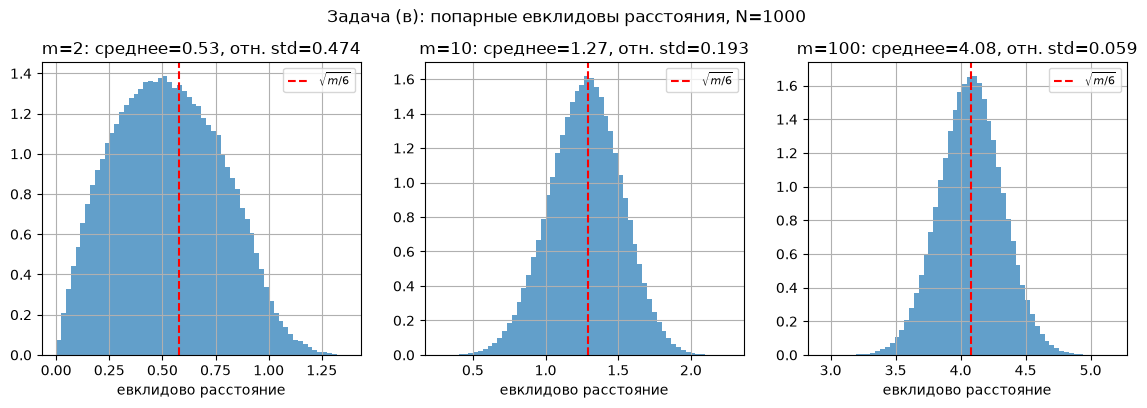

Минимальный радиус шара, содержащего долю p точек (теория):
    m |   r_0.01 |    r_0.1 | вписан. r=1/2 | sqrt(m)/2
    2 |    0.056 |    0.178 |          0.5 |     0.707
   10 |    0.575 |    0.723 |          0.5 |     1.581
  100 |    2.378 |    2.434 |          0.5 |     5.000

Монте-Карло (m=100, N=1000): расстояние до 10-го ближайшего соседа (~1% точек):
  среднее 3.53, min 3.30, max 3.83
  для сравнения: вписанный шар r=0.5, среднее попарное расстояние 4.07


In [4]:
def pairwise_dists(X):
    G = X @ X.T
    d2 = np.diag(G)[:, None] - 2 * G + np.diag(G)[None, :]
    iu = np.triu_indices(len(X), k=1)
    return np.sqrt(np.maximum(d2[iu], 0.0))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, m in zip(axes, [2, 10, 100]):
    d = pairwise_dists(rng.random((1000, m)))
    ax.hist(d, bins=60, density=True, alpha=0.7, color="C0")
    ax.axvline(float(np.sqrt(m / 6)), color="red", ls="--", label=r"$\sqrt{m/6}$")
    ax.set_title(f"m={m}: среднее={d.mean():.2f}, отн. std={d.std() / d.mean():.3f}")
    ax.set_xlabel("евклидово расстояние")
    ax.legend(fontsize=8)
plt.suptitle("Задача (в): попарные евклидовы расстояния, N=1000", y=1.02)
plt.show()

from math import gamma, pi

def r_p(p, m):
    return (p * gamma(m / 2 + 1) / pi ** (m / 2)) ** (1.0 / m)

print("Минимальный радиус шара, содержащего долю p точек (теория):")
print(f"{'m':>5} | {'r_0.01':>8} | {'r_0.1':>8} | {'вписан. r=1/2':>12} | {'sqrt(m)/2':>9}")
for m in [2, 10, 100]:
    print(f"{m:>5} | {r_p(0.01, m):>8.3f} | {r_p(0.1, m):>8.3f} | {'0.5':>12} | {np.sqrt(m) / 2:>9.3f}")

X = rng.random((1000, 100))
G = X @ X.T
d2 = np.diag(G)[:, None] - 2 * G + np.diag(G)[None, :]
np.fill_diagonal(d2, np.inf)
D = np.sqrt(d2)
k = 10
knn_d = np.sort(D, axis=1)[:, k - 1]
print(f"\nМонте-Карло (m=100, N=1000): расстояние до {k}-го ближайшего соседа (~1% точек):")
print(f"  среднее {knn_d.mean():.2f}, min {knn_d.min():.2f}, max {knn_d.max():.2f}")
print(f"  для сравнения: вписанный шар r=0.5, среднее попарное расстояние {pairwise_dists(X).mean():.2f}")


## Задача (г). Расстояния Чебышёва

Для одной координаты равномерных $X_i,Y_i\in[0,1]$ функция распределения $|X_i-Y_i|$:
$$F(t)=P\bigl(|X_i-Y_i|\le t\bigr)=2t-t^2,\qquad 0\le t\le 1.$$
Координаты независимы, поэтому для расстояния Чебышёва $\|X-Y\|_\infty=\max_i|X_i-Y_i|$:
$$P\bigl(\|X-Y\|_\infty\le t\bigr)=\bigl(2t-t^2\bigr)^m.$$
Медиана этого распределения находится из уравнения $2t-t^2=2^{-1/m}$:
$$t_{\text{мед}}=1-\sqrt{1-2^{-1/m}}=1-\sqrt{\frac{\ln 2+o(1)}{m}}\;\xrightarrow[m\to\infty]{}\;1.$$

**Вывод.** При больших $m$ расстояние Чебышёва между почти всеми парами точек выборки близко к максимально возможному значению $1$: расстояния **достаточно велики**, а их относительный разброс убывает как $1/\sqrt m$ (все расстояния почти одинаковы). Для сравнения: медиана евклидова расстояния $\approx\sqrt{m/6}$ растёт как $\sqrt m$. Таким образом, в пространствах большой размерности и евклидовы расстояния, и расстояния Чебышёва между почти всеми точками велики и мало отличаются друг от друга — в этом состоит «проклятие размерности», пагубное для методов, основанных на близости (в частности, для метода ближайших соседей).


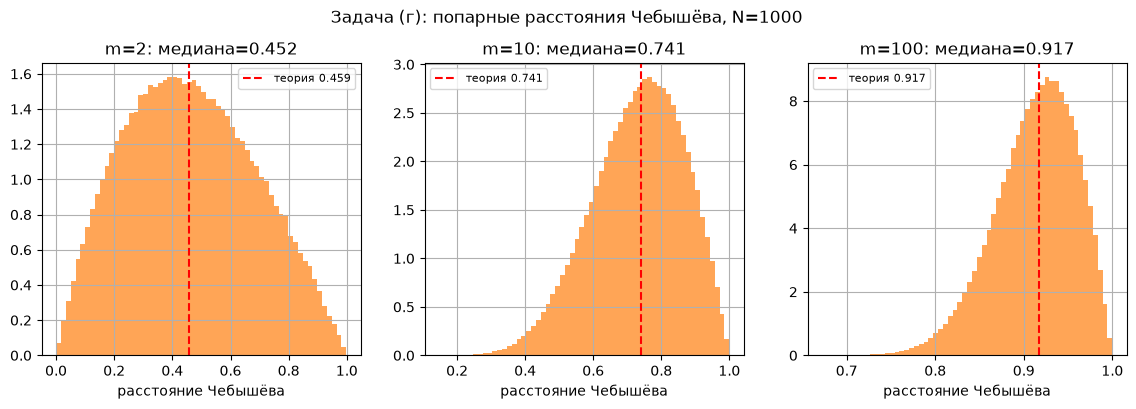

    m | медиана (эксп.) |    теория |  среднее | std/среднее
    2 |          0.4536 |    0.4588 |   0.4614 |      0.4749


   10 |          0.7433 |    0.7412 |   0.7315 |      0.1842


  100 |          0.9166 |    0.9169 |   0.9115 |      0.0506


  300 |          0.9515 |    0.9520 |   0.9485 |      0.0282


In [5]:
def chebyshev_pairwise(X, chunk=100):
    n = len(X)
    D = np.empty((n, n))
    for i in range(0, n, chunk):
        D[i:i + chunk] = np.abs(X[i:i + chunk, None, :] - X[None, :, :]).max(axis=-1)
    iu = np.triu_indices(n, k=1)
    return D[iu]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, m in zip(axes, [2, 10, 100]):
    d = chebyshev_pairwise(rng.random((1000, m)))
    t_med = 1 - np.sqrt(1 - 2 ** (-1.0 / m))
    ax.hist(d, bins=60, density=True, alpha=0.7, color="C1")
    ax.axvline(float(t_med), color="red", ls="--", label=f"теория {t_med:.3f}")
    ax.set_title(f"m={m}: медиана={np.median(d):.3f}")
    ax.set_xlabel("расстояние Чебышёва")
    ax.legend(fontsize=8)
plt.suptitle("Задача (г): попарные расстояния Чебышёва, N=1000", y=1.02)
plt.show()

print(f"{'m':>5} | {'медиана (эксп.)':>15} | {'теория':>9} | {'среднее':>8} | {'std/среднее':>11}")
for m, n, chunk in [(2, 1000, 100), (10, 1000, 100), (100, 1000, 100), (300, 300, 50)]:
    d = chebyshev_pairwise(rng.random((n, m)), chunk)
    t_med = 1 - np.sqrt(1 - 2 ** (-1.0 / m))
    print(f"{m:>5} | {np.median(d):>15.4f} | {t_med:>9.4f} | {d.mean():>8.4f} | {d.std() / d.mean():>11.4f}")


## Задача 4. Распознавание растровых изображений методом ближайшего соседа

**Данные.** Растровые изображения $10\times14$ пикселей со значениями в $[0,1]$: цифры $0$–$9$ (шрифт $5\times7$, растянутый вдвое). Внутриклассовая изменчивость задаётся случайными сдвигами на $\pm2$ пикселя и случайным утолщением/утончением штрихов (морфологические фильтры $2\times2$). Два варианта изображений:

- **бинарные** — пиксели $0/1$;
- **в градациях серого** — сглаженные box-фильтром $3\times3$, пиксели из $[0,1]$.

**Зашумление** (два типа):

- **равномерное** — каждый пиксель независимо с вероятностью $q$ инвертируется (для бинарных) либо заменяется равномерным случайным значением из $[0,1]$ (для градаций серого);
- **неравномерное** — вероятность зашумления зависит от пикселя: $q_j=q_{\max}\,(j+1)/W$ растёт слева направо, правая часть изображения искажена сильнее левой.

**Меры близости** (предложенные выше, плюс косинусная): $L_1$, $L_2$ (евклидова), $L_\infty$ (Чебышёва), $1-\cos(x,y)$.

**Классификатор** — метод $k$ ближайших соседей с голосованием большинством (при равенстве голосов побеждает метка с меньшим номером), $k\in\{1,3,5\}$. Обучающая выборка: $100$ изображений на класс, тестовая: $50$ на класс. Сравнивается процент распознавания на зашумлённой тестовой выборке.


In [6]:
DIGITS_5x7 = [
    [".###.", "#...#", "#..##", "#.#.#", "##..#", "#...#", ".###."],
    ["..#..", ".##..", "..#..", "..#..", "..#..", "..#..", ".###."],
    [".###.", "#...#", "....#", "...#.", "..#..", ".#...", "#####"],
    ["####.", "....#", "....#", ".###.", "....#", "....#", "####."],
    ["#...#", "#...#", "#...#", "#####", "....#", "....#", "....#"],
    ["#####", "#....", "####.", "....#", "....#", "#...#", ".###."],
    ["..##.", ".#...", "#....", "#####", "#...#", "#...#", ".###."],
    ["#####", "....#", "...#.", "..#..", "..#..", "..#..", "..#.."],
    [".###.", "#...#", "#...#", ".###.", "#...#", "#...#", ".###."],
    [".###.", "#...#", "#...#", ".####", "....#", "...#.", ".##.."],
]

def box_blur(img, k=3):
    pad = k // 2
    H, W = img.shape
    p = np.pad(img, pad, mode="edge")
    out = np.zeros_like(img, dtype=float)
    for di in range(k):
        for dj in range(k):
            out += p[di:di + H, dj:dj + W]
    return out / (k * k)

def morph(img, kind):
    if kind == "none":
        return img
    H, W = img.shape
    p = np.pad(img, 1, mode="edge")
    stack = [p[di:di + H, dj:dj + W] for di in range(2) for dj in range(2)]
    out = np.zeros_like(img) if kind == "dilate" else np.ones_like(img)
    fn = np.maximum if kind == "dilate" else np.minimum
    for s in stack:
        out = fn(out, s)
    return out

def template_to_image(tpl, scale=2, blur=False):
    rows = []
    for row in tpl:
        r = "".join("#" * scale if c == "#" else "." * scale for c in row)
        rows.extend([r] * scale)
    img = np.array([[1.0 if c == "#" else 0.0 for c in r] for r in rows])
    return box_blur(img) if blur else img

def random_shift(img, rng, max_shift=1):
    di, dj = rng.integers(-max_shift, max_shift + 1, size=2)
    H, W = img.shape
    out = np.zeros_like(img)
    i0, i1 = max(di, 0), H + min(di, 0)
    j0, j1 = max(dj, 0), W + min(dj, 0)
    out[i0:i1, j0:j1] = img[i0 - di:i1 - di, j0 - dj:j1 - dj]
    return out

def make_dataset(n_per_class, blur, rng, scale=2, max_shift=2):
    X, y = [], []
    for digit, tpl in enumerate(DIGITS_5x7):
        base = template_to_image(tpl, scale=scale, blur=False)
        for _ in range(n_per_class):
            img = morph(base, rng.choice(["erode", "none", "dilate"]))
            if blur:
                img = box_blur(img)
            X.append(random_shift(img, rng, max_shift).ravel())
            y.append(digit)
    return np.asarray(X), np.asarray(y)

X_train_bin, y_train = make_dataset(100, blur=False, rng=rng)
X_test_bin, y_test = make_dataset(50, blur=False, rng=rng)
X_train_gray, _ = make_dataset(100, blur=True, rng=rng)
X_test_gray, _ = make_dataset(50, blur=True, rng=rng)

print("binary:", X_train_bin.shape, X_test_bin.shape)
print("gray:  ", X_train_gray.shape, X_test_gray.shape)
print("классы:", np.unique(y_train))


binary: (1000, 140) (500, 140)
gray:   (1000, 140) (500, 140)
классы: [0 1 2 3 4 5 6 7 8 9]


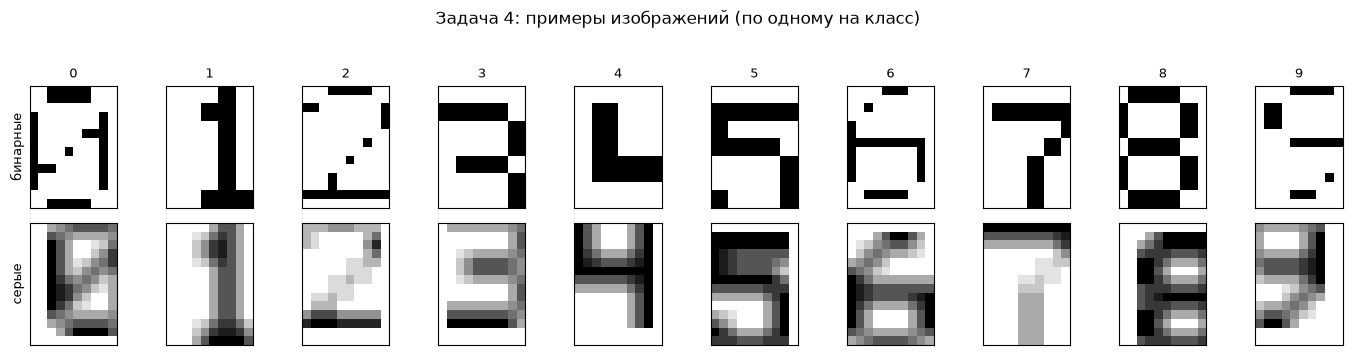

In [7]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.4))
for digit in range(10):
    axes[0, digit].imshow(X_train_bin[y_train == digit][0].reshape(14, 10), cmap="gray_r")
    axes[1, digit].imshow(X_train_gray[y_train == digit][0].reshape(14, 10), cmap="gray_r")
    axes[0, digit].set_title(str(digit), fontsize=9)
for ax_row, name in zip(axes, ["бинарные", "серые"]):
    ax_row[0].set_ylabel(name, fontsize=9)
    for ax in ax_row:
        ax.set_xticks([])
        ax.set_yticks([])
plt.suptitle("Задача 4: примеры изображений (по одному на класс)", y=1.03)
plt.tight_layout()
plt.show()


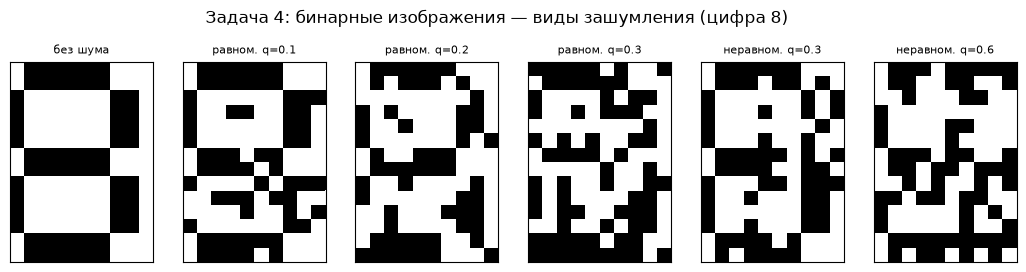

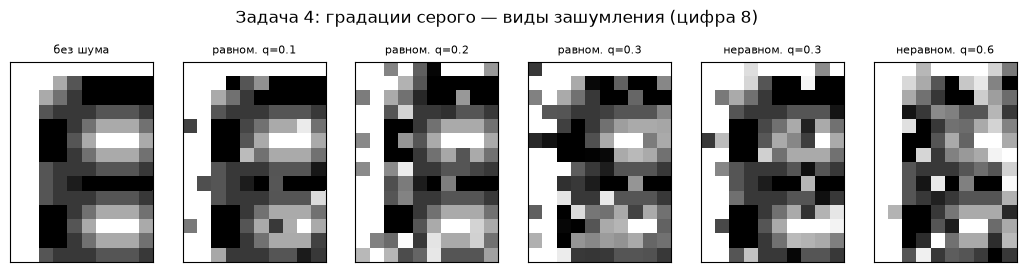

In [8]:
def add_uniform_noise(X, q, binary, rng):
    mask = rng.random(X.shape) < q
    if binary:
        return np.where(mask, 1.0 - X, X)
    return np.where(mask, rng.random(X.shape), X)

def add_nonuniform_noise(X, q_max, binary, rng):
    W = 10
    q_col = q_max * (np.arange(1, W + 1) / W)
    qmap = np.tile(q_col, (14, 1)).ravel()
    mask = rng.random(X.shape) < qmap
    if binary:
        return np.where(mask, 1.0 - X, X)
    return np.where(mask, rng.random(X.shape), X)

def noisy_demo(X, binary, title):
    base = X[y_train == 8][0]
    variants = [
        ("без шума", None),
        ("равном. q=0.1", (0.1, True)),
        ("равном. q=0.2", (0.2, True)),
        ("равном. q=0.3", (0.3, True)),
        ("неравном. q=0.3", (0.3, False)),
        ("неравном. q=0.6", (0.6, False)),
    ]
    fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
    for ax, (name, params) in zip(axes, variants):
        if params is None:
            noisy = base
        else:
            q, uni = params
            fn = add_uniform_noise if uni else add_nonuniform_noise
            noisy = fn(base[None, :], q, binary, rng)[0]
        ax.imshow(noisy.reshape(14, 10), cmap="gray_r")
        ax.set_title(name, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle(title, y=1.08)
    plt.show()

noisy_demo(X_train_bin, True, "Задача 4: бинарные изображения — виды зашумления (цифра 8)")
noisy_demo(X_train_gray, False, "Задача 4: градации серого — виды зашумления (цифра 8)")


In [9]:
METRICS = ["L1", "L2", "Linf", "cosine"]
KS = [1, 3, 5]

def dist_matrix(A, B, metric, chunk=100):
    if metric == "L2":
        na = (A * A).sum(axis=1)[:, None]
        nb = (B * B).sum(axis=1)[None, :]
        return np.sqrt(np.maximum(na - 2 * (A @ B.T) + nb, 0.0))
    if metric == "cosine":
        An = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
        Bn = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
        return 1.0 - An @ Bn.T
    n = len(A)
    D = np.empty((n, len(B)))
    for i in range(0, n, chunk):
        diff = np.abs(A[i:i + chunk, None, :] - B[None, :, :])
        D[i:i + chunk] = diff.sum(-1) if metric == "L1" else diff.max(-1)
    return D

def knn_predict(D, y_train, k):
    idx = np.argpartition(D, k, axis=1)[:, :k]
    preds = np.empty(len(D), dtype=int)
    for i, neighbors in enumerate(y_train[idx]):
        vals, counts = np.unique(neighbors, return_counts=True)
        preds[i] = vals[np.argmax(counts)]
    return preds

def run_experiment(X_train, X_test, y_train, y_test, binary, noise_fn, qs, rng):
    rows = []
    for q in qs:
        X_noisy = noise_fn(X_test, q, binary, rng) if q > 0 else X_test
        for metric in METRICS:
            D = dist_matrix(X_noisy, X_train, metric)
            for k in KS:
                acc = float(np.mean(knn_predict(D, y_train, k) == y_test))
                rows.append({"q": q, "metric": metric, "k": k, "acc": acc})
    return rows

NOISE_LEVELS = {"binary": [0.15, 0.3, 0.45], "gray": [0.3, 0.5, 0.7]}
results = {}
for img_type, Xtr, Xte in [("binary", X_train_bin, X_test_bin), ("gray", X_train_gray, X_test_gray)]:
    for noise_name, fn in [("uniform", add_uniform_noise), ("nonuniform", add_nonuniform_noise)]:
        key = (img_type, noise_name)
        results[key] = run_experiment(Xtr, Xte, y_train, y_test, img_type == "binary",
                                      fn, [0.0] + NOISE_LEVELS[img_type], rng)

def acc_at(rows, q, k, metric):
    for r in rows:
        if r["q"] == q and r["k"] == k and r["metric"] == metric:
            return r["acc"]
    return float("nan")

for (img_type, noise_name), rows in results.items():
    print(f"\n=== {img_type} / {noise_name}: процент распознавания (в ячейке k=1 / k=3 / k=5) ===")
    print(f"{'q':>5} | " + " | ".join(f"{m:>18}" for m in METRICS))
    print("-" * (8 + 21 * len(METRICS)))
    for q in sorted({r["q"] for r in rows}):
        cells = [" / ".join(f"{acc_at(rows, q, k, m):.0%}" for k in KS) for m in METRICS]
        print(f"{q:>5} | " + " | ".join(f"{c:>18}" for c in cells))



=== binary / uniform: процент распознавания (в ячейке k=1 / k=3 / k=5) ===
    q |                 L1 |                 L2 |               Linf |             cosine
--------------------------------------------------------------------------------------------
  0.0 |    88% / 79% / 76% |    88% / 79% / 76% |    80% / 45% / 26% |    91% / 84% / 85%
 0.15 |    88% / 79% / 77% |    88% / 79% / 77% |    10% / 10% / 10% |    92% / 82% / 80%
  0.3 |    77% / 67% / 63% |    77% / 67% / 63% |    10% / 10% / 10% |    50% / 43% / 41%
 0.45 |    17% / 18% / 18% |    17% / 18% / 18% |    10% / 10% / 10% |    12% / 10% / 10%

=== binary / nonuniform: процент распознавания (в ячейке k=1 / k=3 / k=5) ===
    q |                 L1 |                 L2 |               Linf |             cosine
--------------------------------------------------------------------------------------------
  0.0 |    88% / 79% / 76% |    88% / 79% / 76% |    80% / 45% / 26% |    91% / 84% / 85%
 0.15 |    89% / 80% / 77% | 

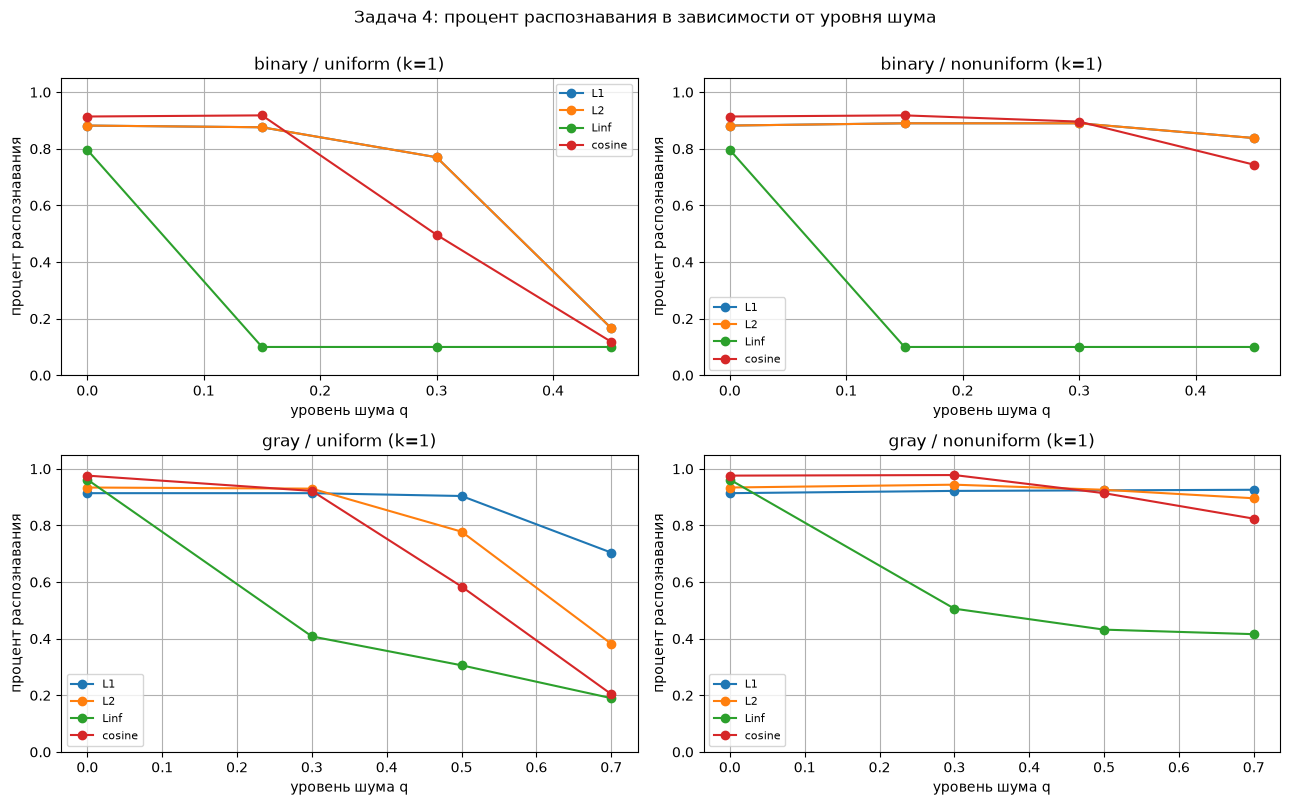

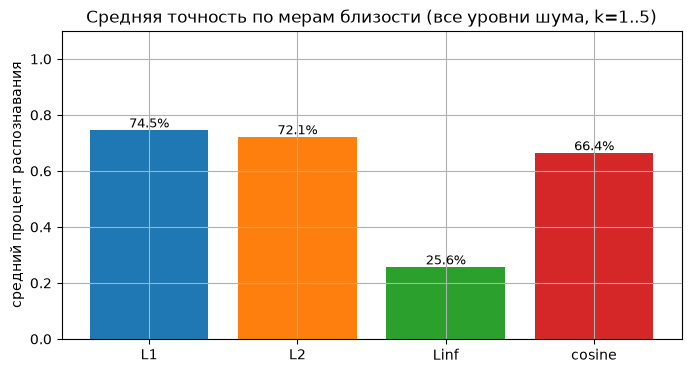

In [10]:
colors = {"L1": "C0", "L2": "C1", "Linf": "C2", "cosine": "C3"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, key in zip(axes.ravel(), [("binary", "uniform"), ("binary", "nonuniform"),
                                  ("gray", "uniform"), ("gray", "nonuniform")]):
    rows = results[key]
    qs = sorted({r["q"] for r in rows})
    for metric in METRICS:
        ax.plot(qs, [acc_at(rows, q, 1, metric) for q in qs], "o-", color=colors[metric], label=metric)
    ax.set_title(f"{key[0]} / {key[1]} (k=1)")
    ax.set_xlabel("уровень шума q")
    ax.set_ylabel("процент распознавания")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
plt.suptitle("Задача 4: процент распознавания в зависимости от уровня шума", y=1.0)
plt.tight_layout()
plt.show()

mean_acc = {}
for metric in METRICS:
    vals = [r["acc"] for rows in results.values() for r in rows
            if r["metric"] == metric and r["q"] > 0]
    mean_acc[metric] = float(np.mean(vals))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mean_acc.keys(), mean_acc.values(), color=[colors[m] for m in mean_acc])
for i, (m, v) in enumerate(mean_acc.items()):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylabel("средний процент распознавания")
ax.set_title("Средняя точность по мерам близости (все уровни шума, k=1..5)")
ax.set_ylim(0, 1.1)
plt.show()


## Выводы

**Проклятие размерности (задачи а–г).** Для выборки из равномерного распределения в $[0,1]^m$:

- **(а)** почти все точки лежат в тонком слое около границы: уже при $m=20$ слой толщины $\delta=0.05$ содержит $\approx 87.9\%$ точек, а при $m=100$ — практически все ($1.0000$); Монте-Карло точно совпадает с теорией $1-(1-2\delta)^m$;
- **(б)** $l_m(p)=p^{1/m}$: $l_5(0.01)=0.398$, $l_5(0.1)=0.631$, $l_{20}(0.01)=0.794$, $l_{20}(0.1)=0.891$; Монте-Карло подтверждает (эмпирические доли $0.0104/0.0990/0.0099/0.1008$);
- **(в)** евклидовы расстояния концентрируются около $\sqrt{m/6}$: при $m=100$ среднее попарное расстояние $4.07$ при относительном разбросе $\approx 1/\sqrt m$; расстояние до 10-го ближайшего соседа ($\sim1\%$ точек) равно $3.53$ — всего на $13\%$ меньше среднего, в 7 раз больше радиуса вписанного шара $r=0.5$ и сравнимо с половиной диагонали куба $5.0$ (теоретическая нижняя оценка $r_{0.01}=2.38$): окрестностям нужен большой радиус;
- **(г)** расстояния Чебышёва стремятся к максимуму: медиана $0.917$ при $m=100$ и $0.952$ при $m=300$ (теория: $0.917/0.952$), относительный разброс падает с $0.051$ до $0.028$ — почти все расстояния велики и одинаковы.

**Задача 4 (kNN, процент распознавания).**

- **Бинарные изображения:** $L_1$ и $L_2$ дают одинаковые результаты (для бинарных векторов $\|x-y\|_2^2=\|x-y\|_1$, порядки совпадают) и лучшие: $88\%$ при $q=0.15$, $77\%$ при $q=0.3$. $L_\infty$ вырождается: расстояния принимают лишь значения $\{0,1\}$, при любом шуме $q>0$ почти все они равны $1$, и kNN даёт случайные $\approx10\%$. Косинусная лучшая на чистых данных ($91\%$), но чувствительна к сильному равномерному шуму ($50\%$ при $q=0.3$, $12\%$ при $q=0.45$).
- **Градации серого:** $L_1$ — самая устойчивая к сильному шуму ($70\%$ при $q=0.7$ против $38\%$ у $L_2$ и $\approx20\%$ у остальных); $L_2$ и косинусная — лучшие при слабом шуме ($93$–$98\%$); $L_\infty$ слаба всюду ($31$–$51\%$ на средних уровнях): расстояние определяется немногими экстремальными пикселями, что согласуется с задачами (в)–(г) — в высоких размерностях расстояния Чебышёва большие и примерно одинаковые.
- **Равномерное vs неравномерное зашумление:** при одном и том же параметре $q$ неравномерное переносится легче (средняя доля искажённых пикселей $\approx0.55q$): $L_1/L_2$ сохраняют $84$–$93\%$ даже при $q_{\max}=0.45$–$0.7$. При сопоставимых *средних* уровнях шума выводы о метриках совпадают.
- **Влияние $k$:** $k=1$ стабильно даёт лучший или равный результат; увеличение $k$ до $3$–$5$ не улучшает, а при сильном шуме и высокой внутриклассовой изменчивости ухудшает распознавание — голосование «размывается» соседями других классов.
- **Общий вывод:** агрегирующие меры ($L_1$, $L_2$) устойчивее к шуму, чем меры, определяемые экстремальными значениями координат ($L_\infty$) — прямое следствие концентрации расстояний: именно «проклятие размерности» делает метод ближайших соседей уязвимым в пространствах большой размерности.
